In [39]:
# ── config ───────────────────────────────────────────────────
PROCESS_PHOTO = "Kinan.Sweidan-22.JPG"  # set to None for all photos
MODEL_VISION = "qwen2.5vl:latest"   # Call 1: image description
MODEL_TAGS   = "qwen2.5:7b"         # Call 2: metadata & tagging

# ── imports ───────────────────────────────────────────────────
from pathlib import Path
from PIL import Image
import base64, urllib.request, json, matplotlib.pyplot as plt

RAW_DIR = Path("./data/raw")
photos = [RAW_DIR / PROCESS_PHOTO] if PROCESS_PHOTO else sorted(
    p for ext in ("*.jpg","*.JPG") for p in RAW_DIR.glob(ext)
)

In [40]:

# ── Call 1: vision description ────────────────────────────────
DESCRIBE_PROMPT = """These are black and white environmental portraits and street photographs taken in Chicago, Illinois.
Do not describe chromatic colors (red, blue, green, yellow, orange, purple, brown, golden) — white, black, and grey are valid tonal descriptors.

Describe this photograph for a blind person in 3-4 sentences. Be literal and specific:
- Who is in the photo, what are they doing, what are they wearing
- What is in the background — objects, architecture, street elements
- Light direction and quality, tonal contrast

IMPORTANT: Only describe what you are 100% certain is visible. If you are not sure what something is, omit it entirely — do not guess and do not include it with a qualifier like "possibly" or "appears to be". Uncertain elements must be left out. If any text (signs, business names) is clearly legible, include it — otherwise say nothing about it."""

# ── Call 2: tagging from description ─────────────────────────
TAG_PROMPT_TEMPLATE = """You are a photo metadata assistant. Based only on the description below, output structured metadata.
Use ONLY the allowed values listed for TAGS — do not invent new ones.
Ignore any elements described with uncertainty (words like possibly, suggest, appear to, might be, could be) — only tag confirmed elements.

DESCRIPTION:
{description}

Output these fields exactly, one per line, no extra text:

NAME: 3 to 8 word wire-service style title
CAPTION: two factual sentences — subject+action, then background
KEYWORDS: exactly 12 lowercase comma-separated SEO terms
CONTENTLOCATION: city and neighborhood if determinable from description, else Unknown
SLUG: lowercase-hyphenated-subject-action-location
TAGS: comma-separated values ONLY from this list — person people elder child street portrait architecture nature fine-art minimalist graphic dramatic mysterious solitude nostalgic joyful sad tense intimate high-contrast backlit overcast silhouette hard-light soft-light light-and-shadow neighborhood train-station bus-station park home alley skyline walking laughing waiting smoking talking running standing sitting dancing grainy gritty rusty
CONFIDENCE: integer 1-5 (how well the description supports the tags)
"""


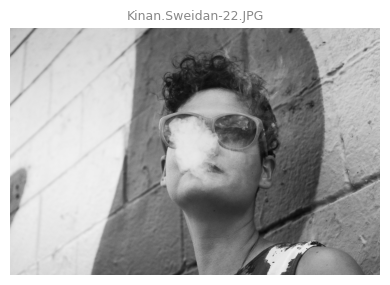

In [41]:

import time
from IPython.display import display as ipy_display, HTML

def ollama(prompt, image_b64=None, model=MODEL_VISION):
    payload = {"model": model, "prompt": prompt, "stream": False}
    if image_b64:
        payload["images"] = [image_b64]
    req = urllib.request.Request(
        "http://localhost:11434/api/generate",
        data=json.dumps(payload).encode(),
        headers={"Content-Type": "application/json"},
    )
    with urllib.request.urlopen(req, timeout=120) as r:
        return json.loads(r.read())["response"]


for path in photos:
    with open(path, "rb") as f:
        img_b64 = base64.b64encode(f.read()).decode()

    # ── Call 1: vision description ────────────────────────────
    t0 = time.time()
    description = ollama(DESCRIBE_PROMPT, image_b64=img_b64, model=MODEL_VISION)
    t1 = time.time()

    # ── Call 2: tagging ───────────────────────────────────────
    tag_prompt = TAG_PROMPT_TEMPLATE.format(description=description)
    # pass image only if MODEL_TAGS is a vision model
    needs_image = "vl" in MODEL_TAGS
    metadata = ollama(tag_prompt, image_b64=img_b64 if needs_image else None, model=MODEL_TAGS)
    t2 = time.time()

    # ── display ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(4, 5))
    ax.imshow(Image.open(path))
    ax.axis("off")
    ax.set_title(path.name, fontsize=9, color="#888")
    plt.tight_layout()
    plt.show()

    ipy_display(HTML(f"""
    <div style="display:grid; grid-template-columns:1fr 1fr; gap:24px; font-family:monospace; font-size:13px; max-width:1100px; margin-top:8px">
      <div>
        <div style="color:#888; font-size:11px; margin-bottom:6px">DESCRIPTION &nbsp;{MODEL_VISION} &nbsp;({t1-t0:.1f}s)</div>
        <div style="white-space:pre-wrap; line-height:1.6">{description}</div>
      </div>
      <div>
        <div style="color:#888; font-size:11px; margin-bottom:6px">METADATA &nbsp;{MODEL_TAGS} &nbsp;({t2-t1:.1f}s)</div>
        <div style="white-space:pre-wrap; line-height:1.8">{metadata}</div>
      </div>
    </div>
    <div style="color:#aaa; font-size:11px; margin-top:12px">Total: {t2-t0:.1f}s</div>
    <hr style="margin:20px 0; border:none; border-top:1px solid #eee">
    """))
